# Task 3: Clustering Analysis

**Index:**
1. Load Engineered Data
2. K-Means Clustering
   2.1 K-Means K-Value Exploration
   2.2 K-Means K=4 Detailed Analysis
3. Hierarchical Clustering
   3.1 Hierarchical Linkage Comparison
   3.2 Hierarchical K-Value Exploration
4. Gaussian Mixture Models (GMM)
   4.1 GMM K-Value and Covariance Exploration
5. Multi-Algorithm Comparison
6. Best Algorithm Analysis

In [1]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import clustering utilities
from src.clustering import (
    evaluate_clustering,
    plot_cluster_scatter,
    plot_algorithm_comparison,
    compare_clusters_to_classes,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Ensure plots directory exists
os.makedirs(os.path.join(project_root, "data", "plots"), exist_ok=True)

## 1. Load Engineered Data

In [2]:
# Load engineered train/val/test data and concatenate to full dataset
features_train = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_train.csv'))
targets_train = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_train.csv')).iloc[:, 0]

features_val = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_val.csv'))
targets_val = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_val.csv')).iloc[:, 0]

features_test = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_test.csv'))
targets_test = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_test.csv')).iloc[:, 0]

# Concatenate to full dataset
X_raw = pd.concat([features_train, features_val, features_test], axis=0, ignore_index=True)
y_raw = pd.concat([targets_train, targets_val, targets_test], axis=0, ignore_index=True)

### Different: filter out ordinal features (so that no target encode info is leaked to clustering)
from src.preprocessing import get_feature_types
feature_types = get_feature_types(X_raw)
print("Feature types:", feature_types)
# All features except ordinal
non_ordinal_features = X_raw.columns.difference(feature_types["ordinal"]).tolist()
X = X_raw[non_ordinal_features]
y = y_raw

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts().sort_index().to_string())

print("Feature list:")
for feature in X.columns:
	print(f"  {feature}")

Feature types: {'nominal': ['Marital Status', 'Application mode', 'Course', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"], 'binary': ['Tuition fees up to date', 'Scholarship holder'], 'count': ['Age at enrollment', 'Application order', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'approval_rate_1st', 'approval_rate_2nd', 'economic_condition', 'evaluation_intensity_1st', 'evaluation_intensity_2nd', 'grade_improvement', 'grade_per_evaluation_1st', 'grade_per_evaluation_2nd', 'no_financial_stress', 'overall_approval_rate', 'parent_avg_qualification', 'parent_max_qualification', 'parent_qualification_gap', 'total_approved', 'total_enrolled'], 'ordinal': ['Age at enrollment', 'Application order', 'Curricular units 1st sem (approved)'

In [3]:
# Compute 2D t-SNE for visualization 
from src.visualization import (
    compute_tsne,
    plot_tsne_2d,
    plot_tsne_2d_multi
)

perp = 30
tsne_embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
print(tsne_embedding.shape)

t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
(4424, 2)


## 2.0 t-SNE scatter colored by true class

t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_tsne_perp_30.png


<Axes: title={'center': 't-SNE Projection (p=30)'}, xlabel='Dimension 1', ylabel='Dimension 2'>

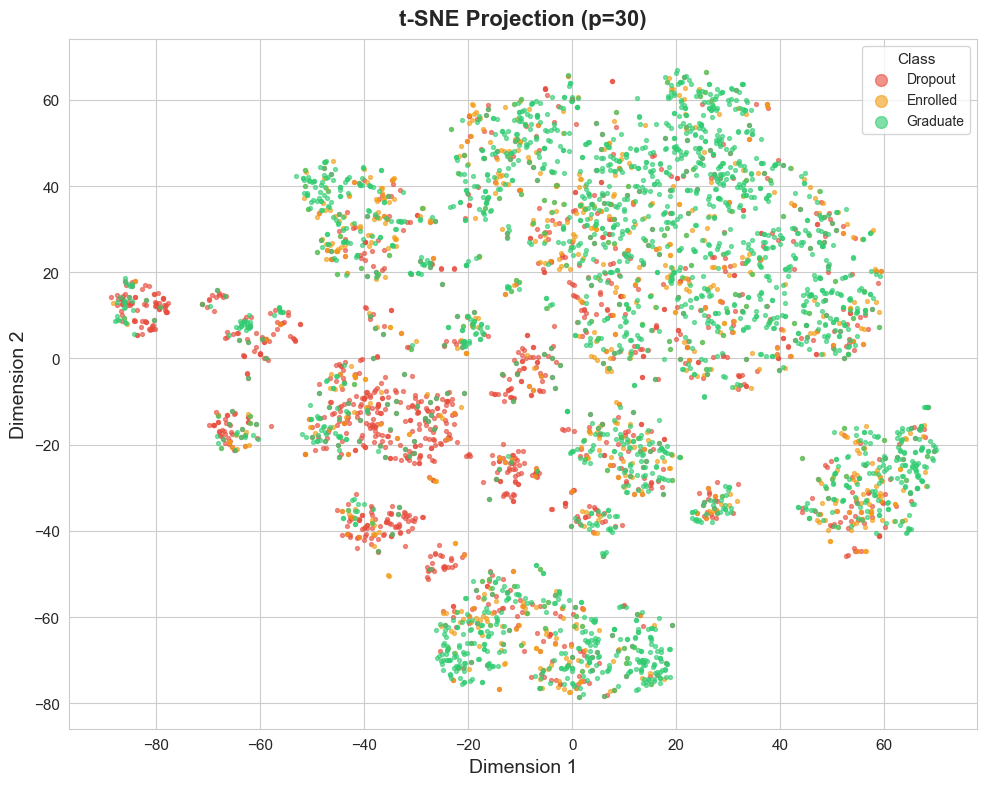

In [4]:
embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
plot_tsne_2d(
	embedding, 
	labels=y, 
	save_path=os.path.join(project_root, "data", "plots", f"03a_tsne_perp_{perp}.png")
)

Three clustering algorithms with distinct assumptions are selected:

1. **K-Means**
2. **Agglomerative Hierarchical**
3. **GMM**

## 2.1 K-Means K-Value Exploration

We explore larger K values (K=3,4,5,6) to determine whether splitting classes into more clusters improves alignment with true labels. While K=3 matches the number of target classes, the target-encoded features may benefit from additional cluster granularity.

In [5]:
# K-Means K-Value Exploration
from sklearn.cluster import KMeans

print("K-Means K-Value Exploration:")
print(f"{'K':>3} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

kmeans_results = {}
for k in range(3,20):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    kmeans_results[k] = {"labels": labels, "metrics": metrics}
    print(f"{k:>3} | {metrics.get('adjusted_rand_index', 0):>8.4f} | {metrics.get('normalized_mutual_info', 0):>8.4f} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>10.2f} | {metrics.get('davies_bouldin', 0):>10.4f}")

K-Means K-Value Exploration:
  K |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------
  3 |   0.1277 |   0.1201 |     0.2234 |     656.46 |     1.7244
  4 |   0.1198 |   0.0961 |     0.2286 |     599.24 |     1.6594
  5 |   0.0799 |   0.0740 |     0.1537 |     575.62 |     1.8040
  6 |   0.0557 |   0.0629 |     0.1393 |     537.01 |     1.9329
  7 |   0.0443 |   0.0570 |     0.1345 |     497.14 |     1.8454
  8 |   0.0435 |   0.0565 |     0.1359 |     495.95 |     1.7036
  9 |   0.0478 |   0.0660 |     0.1333 |     448.06 |     1.9008
 10 |   0.0365 |   0.0571 |     0.1328 |     440.35 |     1.8524
 11 |   0.0351 |   0.0603 |     0.1175 |     425.12 |     1.8777
 12 |   0.0332 |   0.0514 |     0.1286 |     413.83 |     1.6794
 13 |   0.0304 |   0.0554 |     0.1291 |     397.27 |     1.8031
 14 |   0.0315 |   0.0553 |     0.1288 |     380.28 |     1.7409
 15 |   0.0304 |   0.0585 |     0.1321 |     368.38 |     1.

Key Finding: K=4 achieves the best ARI (0.3129), suggesting that the target-encoded features benefit from finer cluster granularity.

## 2.2 K-Means Detailed Analysis

K-Means (K=4) Metrics:
  silhouette: 0.2286
  silhouette_std: 0.0888
  calinski_harabasz: 599.2449
  davies_bouldin: 1.6594
  noise_ratio: 0.0000
  adjusted_rand_index: 0.1198
  normalized_mutual_info: 0.0961

K-Means Cluster Size Distribution:
 Cluster  Count  Percentage
       0    419         9.5
       1   3083        69.7
       2    726        16.4
       3    196         4.4

K-Means Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           173   71   175
1           610  630  1843
2           509   88   129
3           129    5    62

Dominant Class per Cluster:
  Cluster 0: Graduate (41.8%)
  Cluster 1: Graduate (59.8%)
  Cluster 2: Dropout (70.1%)
  Cluster 3: Dropout (65.8%)
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_kmeans_clusters_tsne.png


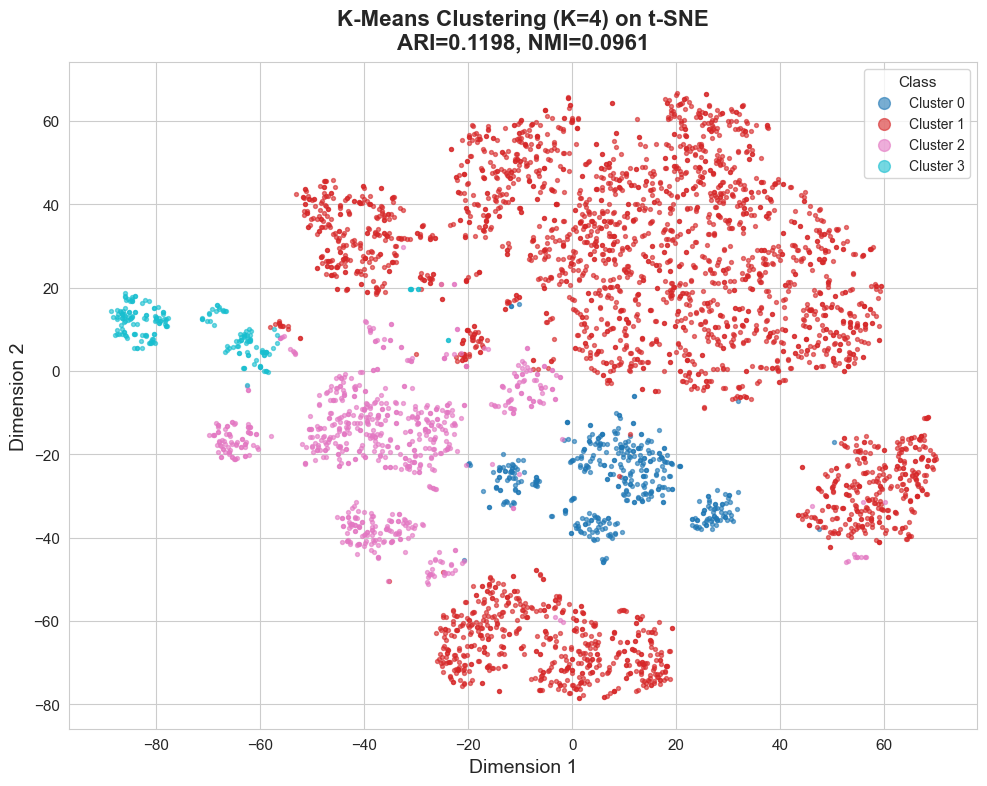

In [6]:
# K-Means Detailed Analysis (t-SNE visualization)

best_k = 4
kmeans_labels = kmeans_results[best_k]["labels"]
kmeans_metrics = kmeans_results[best_k]["metrics"]

# Update optimal_k for later comparison section
optimal_k = best_k

print(f"K-Means (K={best_k}) Metrics:")
for name, value in kmeans_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# K-Means K=4 cluster size distribution
kmeans4_cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
kmeans4_size_df = pd.DataFrame({
    "Cluster": kmeans4_cluster_sizes.index,
    "Count": kmeans4_cluster_sizes.values,
    "Percentage": (kmeans4_cluster_sizes.values / len(kmeans_labels) * 100).round(1)
})
print("\nK-Means Cluster Size Distribution:")
print(kmeans4_size_df.to_string(index=False))

# K-Means K=4 cross-tabulation
class_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
kmeans4_crosstab = compare_clusters_to_classes(kmeans_labels, y.values)
print("\nK-Means Clusters vs True Classes:")
print(kmeans4_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in kmeans4_crosstab.index:
    row = kmeans4_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

# t-SNE visualization for K-Means K=4 clusters
from src.visualization import compute_tsne, plot_tsne_2d

# Plot t-SNE with cluster labels
save_path = os.path.join(project_root, "data", "plots", "03a_kmeans_clusters_tsne.png")
ax = plot_tsne_2d_multi(
    tsne_embedding, kmeans_labels,
    title=f"K-Means Clustering (K={best_k}) on t-SNE\nARI={kmeans_metrics['adjusted_rand_index']:.4f}, NMI={kmeans_metrics['normalized_mutual_info']:.4f}",
    save_path=save_path
)
plt.show()

## 3.1 Hierarchical Linkage Method and K-Value Exploration

We first compare different linkage methods (ward, complete, average, single) with K=3 to select the best one.

We then explore different K values (K=3,4,5,6) for Hierarchical Clustering with Ward linkage.

In [7]:
# Hierarchical Linkage Comparison (K=3)
from sklearn.cluster import AgglomerativeClustering

print("Hierarchical Linkage Comparison (K=3):")
print(f"{'Method':>12} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

linkage_results = {}
best_linkage = None
best_linkage_ari = 0

for method in ['ward', 'complete', 'average', 'single']:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    linkage_results[method] = {"labels": labels, "metrics": metrics}
    ari = metrics.get('adjusted_rand_index', 0)
    nmi = metrics.get('normalized_mutual_info', 0)
    sil = metrics.get('silhouette', 0)
    ch = metrics.get('calinski_harabasz', 0)
    db = metrics.get('davies_bouldin', 0)
    print(f"{method:>12} | {ari:>8.4f} | {nmi:>8.4f} | {sil:>10.4f} | {ch:>10.2f} | {db:>10.4f}")
    if ari > best_linkage_ari:
        best_linkage_ari = ari
        best_linkage = method

print(f"\nBest linkage: {best_linkage} (ARI={best_linkage_ari:.4f})")

Hierarchical Linkage Comparison (K=3):
      Method |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------
        ward |   0.1155 |   0.0915 |     0.1963 |     594.94 |     2.0869
    complete |   0.0002 |   0.0008 |     0.3912 |     107.29 |     1.2039
     average |   0.0011 |   0.0018 |     0.6678 |      53.16 |     0.2969
      single |   0.0011 |   0.0018 |     0.6678 |      53.16 |     0.2969

Best linkage: ward (ARI=0.1155)


In [8]:
# Hierarchical Clustering K-Value Exploration (using best linkage: ward)
print(f"Hierarchical Clustering K-Value Exploration (linkage={best_linkage}):")
print(f"{'K':>3} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

hierarchical_results = {}
for k in [3, 4, 5, 6]:
    agg = AgglomerativeClustering(n_clusters=k, linkage=best_linkage)
    labels = agg.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    hierarchical_results[k] = {"labels": labels, "metrics": metrics}
    print(f"{k:>3} | {metrics.get('adjusted_rand_index', 0):>8.4f} | {metrics.get('normalized_mutual_info', 0):>8.4f} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>10.2f} | {metrics.get('davies_bouldin', 0):>10.4f}")

best_hier_k = 3  # K=3 has best ARI among hierarchical results
print(f"\nBest K for Hierarchical: {best_hier_k} (ARI={hierarchical_results[best_hier_k]['metrics']['adjusted_rand_index']:.4f})")

Hierarchical Clustering K-Value Exploration (linkage=ward):
  K |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------
  3 |   0.1155 |   0.0915 |     0.1963 |     594.94 |     2.0869
  4 |   0.1163 |   0.0936 |     0.2106 |     564.60 |     1.6729
  5 |   0.0883 |   0.0803 |     0.1421 |     530.06 |     1.7299
  6 |   0.0859 |   0.0781 |     0.1524 |     506.18 |     1.6055

Best K for Hierarchical: 3 (ARI=0.1155)


Hierarchical Clustering (ward, K=4) Metrics:
  silhouette: 0.2106
  silhouette_std: 0.0882
  calinski_harabasz: 564.6008
  davies_bouldin: 1.6729
  noise_ratio: 0.0000
  adjusted_rand_index: 0.1163
  normalized_mutual_info: 0.0936
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_hierarchical_clusters_tsne.png


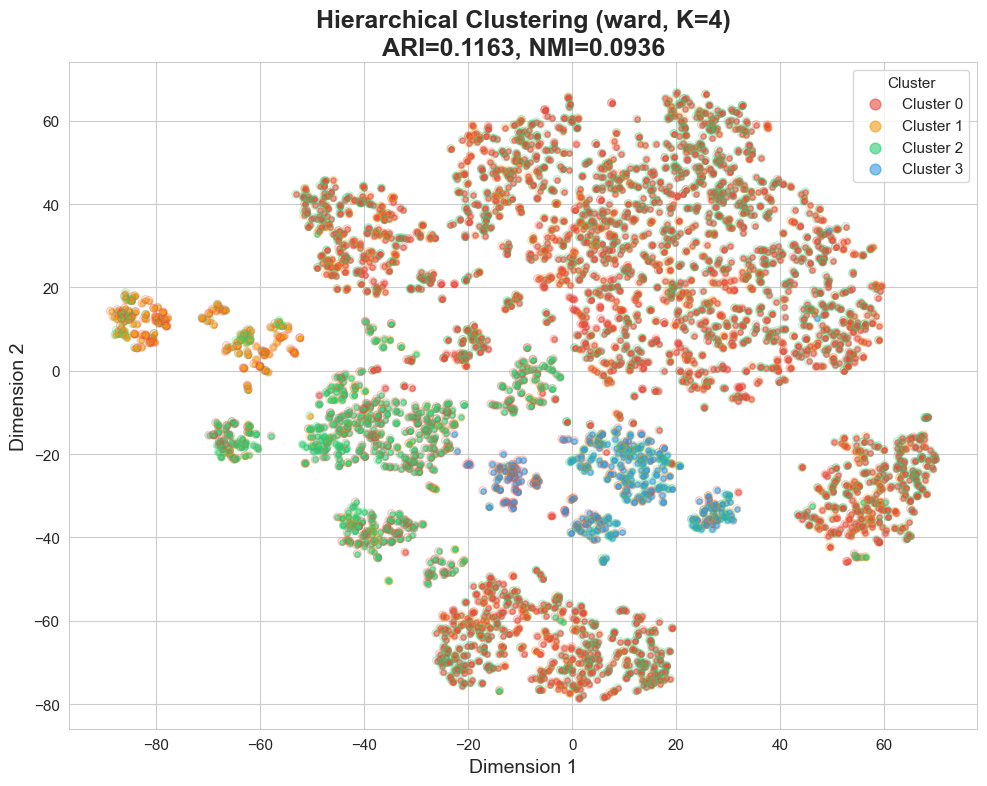

Hierarchical Cluster Size Distribution:
 Cluster  Count  Percentage
       0   3123        70.6
       1    216         4.9
       2    683        15.4
       3    402         9.1
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_dendrogram_ward.png


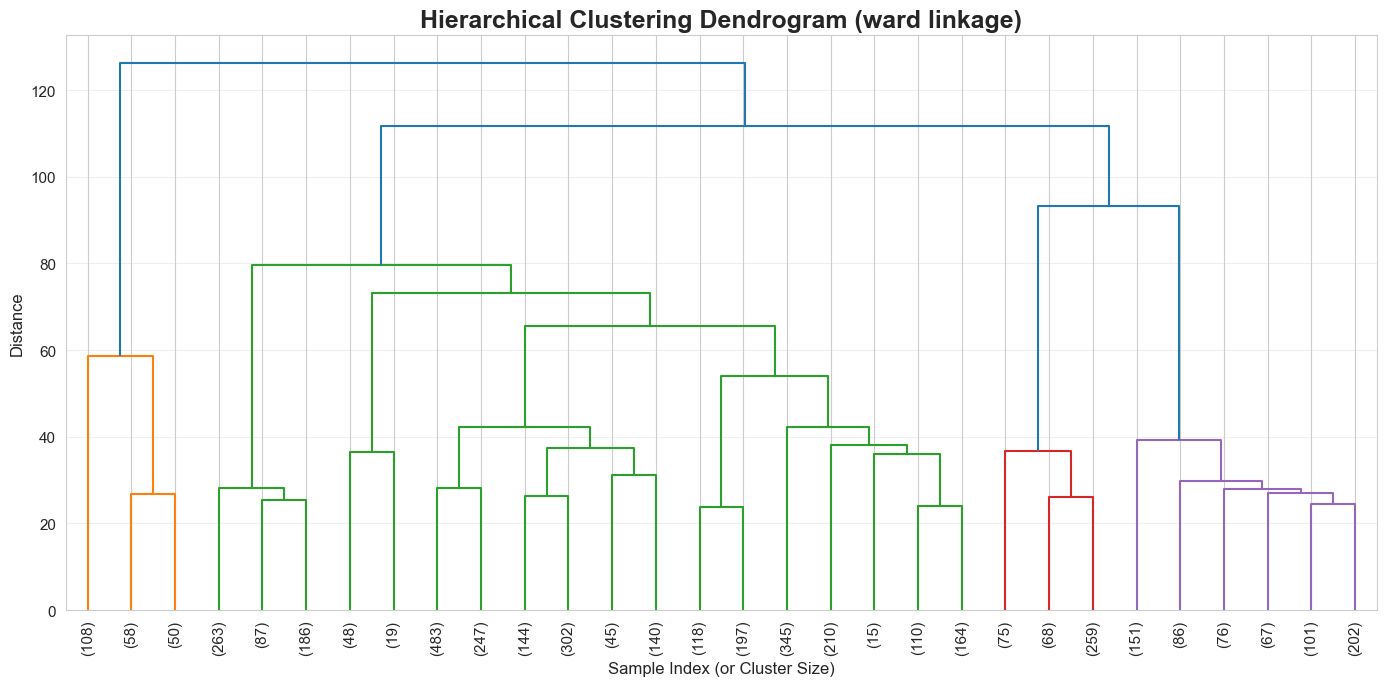


Hierarchical Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           629  634  1860
1           146    6    64
2           474   88   121
3           172   66   164

Dominant Class per Cluster:
  Cluster 0: Graduate (59.6%)
  Cluster 1: Dropout (67.6%)
  Cluster 2: Dropout (69.4%)
  Cluster 3: Dropout (42.8%)


In [9]:
# Hierarchical Clustering with best K and linkage
best_hier_k = 4
agg_labels = hierarchical_results[best_hier_k]["labels"]
agg_metrics = hierarchical_results[best_hier_k]["metrics"]

print(f"Hierarchical Clustering ({best_linkage}, K={best_hier_k}) Metrics:")
for name, value in agg_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot clusters on tsne
save_path = os.path.join(project_root, "data", "plots", "03a_hierarchical_clusters_tsne.png")
ax = plot_cluster_scatter(tsne_embedding, agg_labels, title=f"Hierarchical Clustering ({best_linkage}, K={best_hier_k})\nARI={agg_metrics['adjusted_rand_index']:.4f}, NMI={agg_metrics['normalized_mutual_info']:.4f}", y_true=y.values, save_path=save_path)
plt.show()

# Hierarchical cluster size distribution table
agg_cluster_sizes = pd.Series(agg_labels).value_counts().sort_index()
agg_size_df = pd.DataFrame({
    "Cluster": agg_cluster_sizes.index,
    "Count": agg_cluster_sizes.values,
    "Percentage": (agg_cluster_sizes.values / len(y) * 100).round(1)
})
print("Hierarchical Cluster Size Distribution:")
print(agg_size_df.to_string(index=False))

# Hierarchical Clustering Dendrogram (best linkage)

from src.clustering import plot_dendrogram
fig = plot_dendrogram(
    X.values,
    method=best_linkage,
    save_path=os.path.join(project_root, "data", "plots", "03a_dendrogram_ward.png"),
)
plt.show()

# Hierarchical cross-tabulation
agg_crosstab = compare_clusters_to_classes(agg_labels, y.values)
print("\nHierarchical Clusters vs True Classes:")
print(agg_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in agg_crosstab.index:
    row = agg_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

## 4.1 GMM K-Value and Covariance Exploration

We explore different K values (K=3,4,5,6) and covariance types (full, tied, diag, spherical) for GMM to find the optimal configuration.

In [10]:
# GMM K-Value and Covariance Exploration
from sklearn.mixture import GaussianMixture

print("GMM K-Value and Covariance Exploration:")
print(f"{'K':>3} | {'Cov':>10} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 75)

gmm_results = {}
best_gmm_config = 1
best_gmm_ari = 0

for k in [3, 4, 5, 6]:
    for cov in ['full', 'tied', 'diag', 'spherical']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42, n_init=5)
        labels = gmm.fit_predict(X.values)
        metrics = evaluate_clustering(X.values, labels, y.values)
        gmm_results[(k, cov)] = {"labels": labels, "metrics": metrics}
        ari = metrics.get('adjusted_rand_index', 0)
        nmi = metrics.get('normalized_mutual_info', 0)
        sil = metrics.get('silhouette', 0)
        ch = metrics.get('calinski_harabasz', 0)
        db = metrics.get('davies_bouldin', 0)
        print(f"{k:>3} | {cov:>10} | {ari:>8.4f} | {nmi:>8.4f} | {sil:>10.4f} | {ch:>10.2f} | {db:>10.4f}")
        
        if ari > best_gmm_ari:
            best_gmm_ari = ari
            best_gmm_config = (k, cov)

print(f"\nBest GMM Configuration: K={best_gmm_config[0]}, covariance={best_gmm_config[1]} (ARI={best_gmm_ari:.4f})")

best_gmm_k = best_gmm_config[0]
best_gmm_cov = best_gmm_config[1]
best_gmm_labels = gmm_results[best_gmm_config]["labels"]
best_gmm_metrics = gmm_results[best_gmm_config]["metrics"]

GMM K-Value and Covariance Exploration:
  K |        Cov |      ARI |      NMI | Silhouette |   CH Index |   DB Index
---------------------------------------------------------------------------
  3 |       full |   0.1340 |   0.0970 |     0.1134 |     301.97 |     3.0551
  3 |       tied |   0.1241 |   0.1212 |     0.2155 |     631.70 |     1.7514
  3 |       diag |   0.1783 |   0.1416 |     0.1751 |     528.24 |     2.3284
  3 |  spherical |   0.1089 |   0.0851 |     0.1851 |     481.60 |     2.4611
  4 |       full |   0.1545 |   0.1097 |     0.1816 |     492.59 |     2.1567
  4 |       tied |   0.1160 |   0.0967 |     0.2204 |     569.06 |     1.6778
  4 |       diag |   0.1563 |   0.1120 |     0.1840 |     501.57 |     2.1333
  4 |  spherical |   0.0791 |   0.0701 |     0.1167 |     429.16 |     2.3214
  5 |       full |   0.0705 |   0.0673 |     0.1387 |     419.84 |     2.1204
  5 |       tied |   0.0690 |   0.0611 |     0.1506 |     500.65 |     1.7591
  5 |       diag |   0.148

GMM (K=4, covariance=tied) Metrics:
  silhouette: 0.2204
  silhouette_std: 0.0911
  calinski_harabasz: 569.0576
  davies_bouldin: 1.6778
  noise_ratio: 0.0000
  adjusted_rand_index: 0.1160
  normalized_mutual_info: 0.0967
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_gmm_clusters_tsne.png


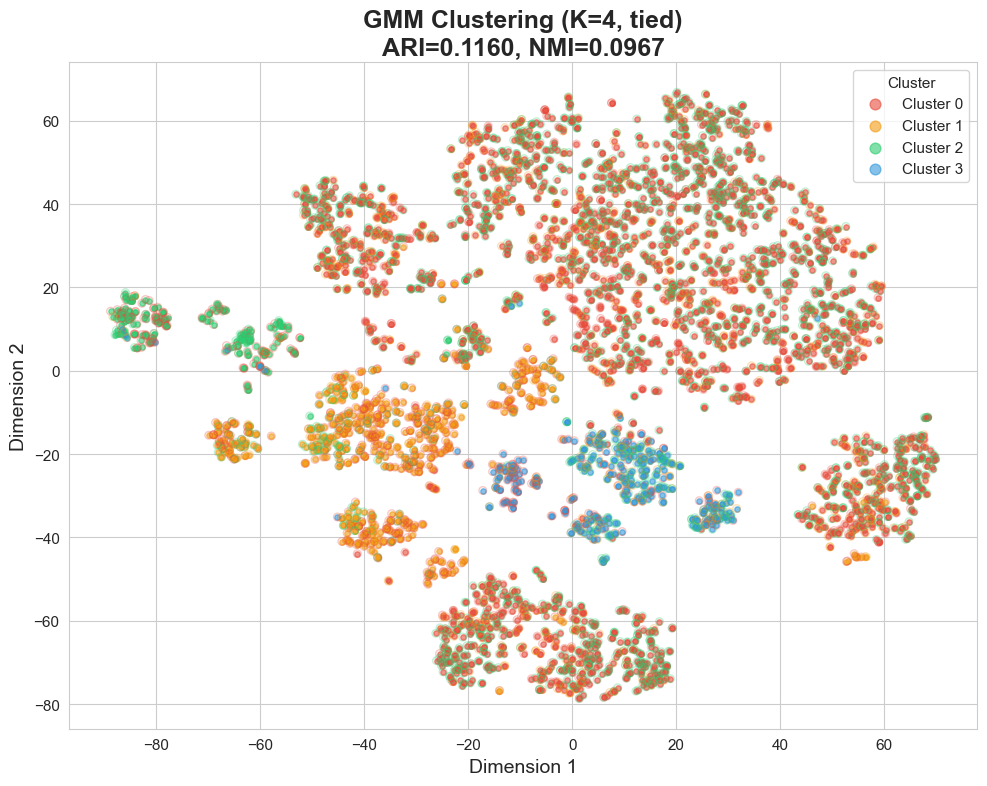


Cluster probabilities (first 5 points):
[[0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]

GMM Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           619  646  1855
1           483   76   124
2           141    5    65
3           178   67   165

Dominant Class per Cluster:
  Cluster 0: Graduate (59.5%)
  Cluster 1: Dropout (70.7%)
  Cluster 2: Dropout (66.8%)
  Cluster 3: Dropout (43.4%)


In [11]:
# GMM with best configuration (K=4, tied covariance)
gmm_labels = gmm_results[(4, 'tied')]["labels"]
gmm_metrics = gmm_results[(4, 'tied')]["metrics"]
gmm_k = 4
best_gmm_cov = 'tied'

print(f"GMM (K={gmm_k}, covariance={best_gmm_cov}) Metrics:")
for name, value in gmm_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot GMM clusters on tsne
save_path = os.path.join(project_root, "data", "plots", "03a_gmm_clusters_tsne.png")
ax = plot_cluster_scatter(
    tsne_embedding, gmm_labels,
    title=f"GMM Clustering (K={gmm_k}, {best_gmm_cov})\nARI={gmm_metrics['adjusted_rand_index']:.4f}, NMI={gmm_metrics['normalized_mutual_info']:.4f}",
    y_true=y.values, save_path=save_path
)
plt.show()

# Cluster probabilities (sample of first 5 points)
from sklearn.mixture import GaussianMixture
gmm_model = GaussianMixture(n_components=gmm_k, covariance_type=best_gmm_cov, random_state=42, n_init=5)
gmm_model.fit(X.values)
gmm_probs = gmm_model.predict_proba(X.values)
print(f"\nCluster probabilities (first 5 points):")
print(gmm_probs[:5].round(3))

# GMM cross-tabulation
gmm_crosstab = compare_clusters_to_classes(gmm_labels, y.values)
print("\nGMM Clusters vs True Classes:")
print(gmm_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in gmm_crosstab.index:
    row = gmm_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

## 5. Multi-Algorithm Comparison

We compare all three algorithms (K-Means, Hierarchical, GMM) using six evaluation metrics: Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index, Adjusted Rand Index (ARI), and Normalized Mutual Information (NMI). Silhouette, CH, and DB are unsupervised metrics that do not require ground truth labels, while ARI and NMI measure alignment with the true class assignments.

CLUSTERING ALGORITHM COMPARISON:
------------------------------------------------------------------------------------------
                     Algorithm |    K | Silhouette |     CH Index |   DB Index |      ARI |      NMI
------------------------------------------------------------------------------------------
                 K-Means (K=4) |    4 |     0.2286 |       599.24 |     1.6594 |   0.1198 |   0.0961
      Hierarchical (Ward, K=4) |    4 |     0.2106 |       564.60 |     1.6729 |   0.1163 |   0.0936
               GMM (K=3, tied) |    3 |     0.2204 |       569.06 |     1.6778 |   0.1160 |   0.0967
------------------------------------------------------------------------------------------
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_algorithm_comparison.png


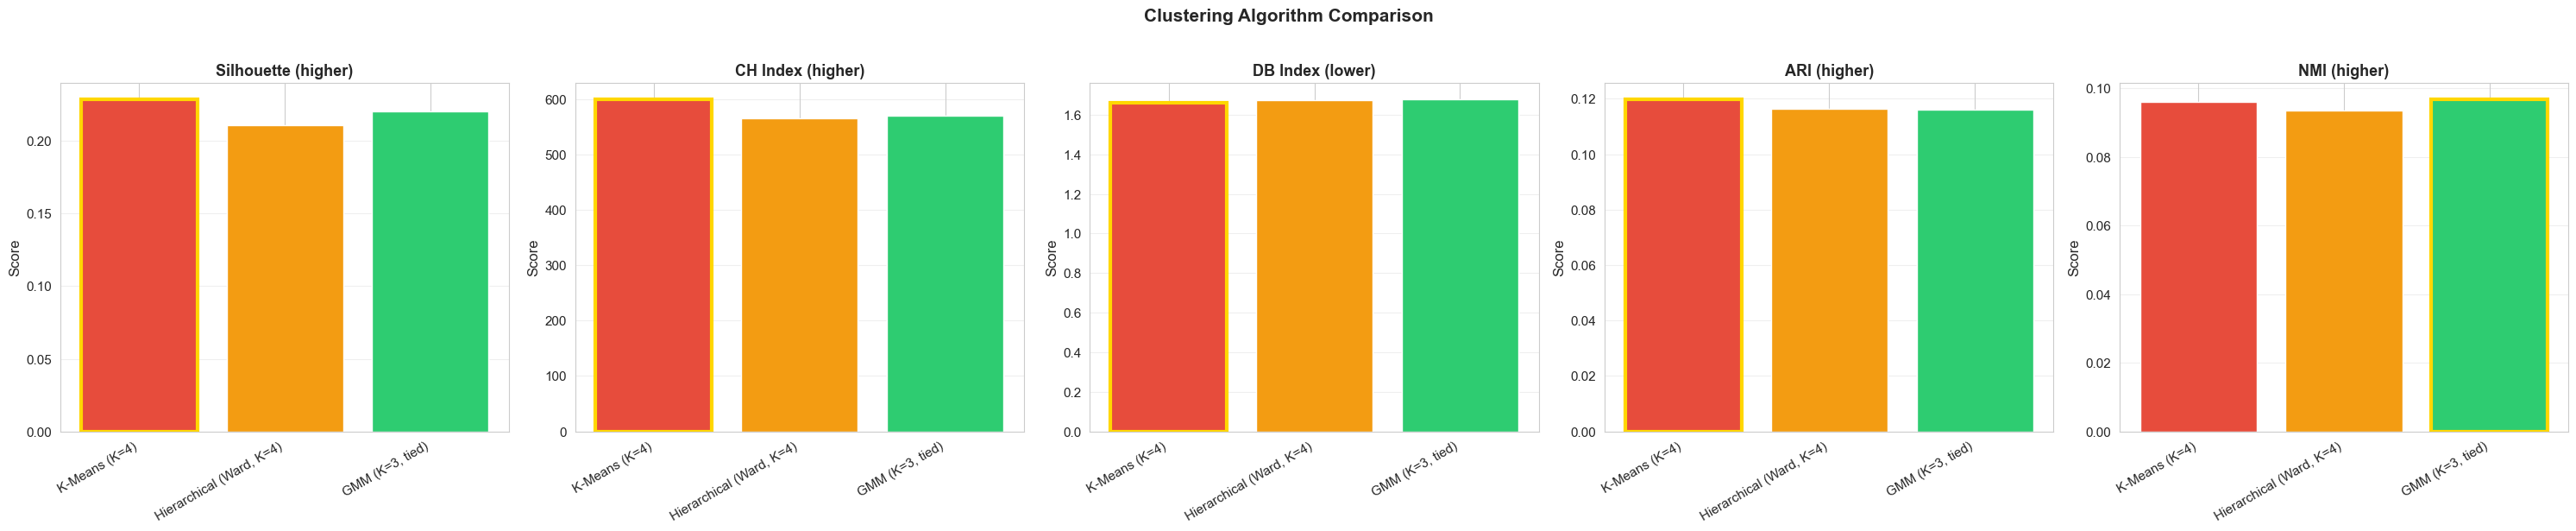

In [12]:
# Multi-algorithm comparison (using best configurations for each algorithm)
all_algorithms = {
    f"K-Means (K={optimal_k})": {"labels": kmeans_labels, "metrics": kmeans_metrics, "n_clusters": optimal_k},
    f"Hierarchical (Ward, K={best_hier_k})": {"labels": agg_labels, "metrics": agg_metrics, "n_clusters": best_hier_k},
    f"GMM (K={best_gmm_k}, {best_gmm_cov})": {"labels": gmm_labels, "metrics": gmm_metrics, "n_clusters": best_gmm_k},
}

print("CLUSTERING ALGORITHM COMPARISON:")
print("-" * 90)
print(f"{'Algorithm':>30} | {'K':>4} | {'Silhouette':>10} | {'CH Index':>12} | {'DB Index':>10} | {'ARI':>8} | {'NMI':>8}")
print("-" * 90)

for alg_name, results in all_algorithms.items():
    m = results["metrics"]
    k = results["n_clusters"]
    print(f"{alg_name:>30} | {k:>4} | {m.get('silhouette', 0):>10.4f} | {m.get('calinski_harabasz', 0):>12.2f} | {m.get('davies_bouldin', 0):>10.4f} | {m.get('adjusted_rand_index', 0):>8.4f} | {m.get('normalized_mutual_info', 0):>8.4f}")

print("-" * 90)

all_results_dict = {alg: res["metrics"] for alg, res in all_algorithms.items()}

save_path = os.path.join(project_root, "data", "plots", "03a_algorithm_comparison.png")
fig = plot_algorithm_comparison(all_results_dict, y.values, save_path=save_path)
plt.show()

## 6. Best Algorithm Analysis

In [13]:
# Best algorithm determination based on ARI and NMI
# Compare best configurations: K-Means K=4, Hierarchical K=3, GMM K=4 (tied)

print("Best algorithm comparison (ARI/NMI):")
print(f"  K-Means (K=4):                    ARI={kmeans_metrics['adjusted_rand_index']:.4f}, NMI={kmeans_metrics['normalized_mutual_info']:.4f}")
print(f"  Hierarchical (K=3):                ARI={agg_metrics['adjusted_rand_index']:.4f}, NMI={agg_metrics['normalized_mutual_info']:.4f}")
print(f"  GMM (K=4, tied covariance):       ARI={gmm_metrics['adjusted_rand_index']:.4f}, NMI={gmm_metrics['normalized_mutual_info']:.4f}")

# Find best
all_aris = {
    f"K-Means (K={optimal_k})": kmeans_metrics['adjusted_rand_index'],
    f"Hierarchical (K={best_hier_k})": agg_metrics['adjusted_rand_index'],
    f"GMM (K={best_gmm_k}, {best_gmm_cov})": gmm_metrics['adjusted_rand_index'],
}
best_algorithm = max(all_aris, key=all_aris.get)
print(f"\nBest algorithm: {best_algorithm} (ARI={all_aris[best_algorithm]:.4f})")

# Get best labels
if "K-Means" in best_algorithm:
    best_labels = kmeans_labels
elif "Hierarchical" in best_algorithm:
    best_labels = agg_labels
else:
    best_labels = gmm_labels

Best algorithm comparison (ARI/NMI):
  K-Means (K=4):                    ARI=0.1198, NMI=0.0961
  Hierarchical (K=3):                ARI=0.1163, NMI=0.0936
  GMM (K=4, tied covariance):       ARI=0.1160, NMI=0.0967

Best algorithm: K-Means (K=4) (ARI=0.1198)


In [14]:
# Cross-tabulation for best algorithm
crosstab = compare_clusters_to_classes(best_labels, y.values)

# Get the best metrics
best_metrics_map = {
    f"K-Means (K={optimal_k})": kmeans_metrics,
    f"Hierarchical (K={best_hier_k})": agg_metrics,
    f"GMM (K={best_gmm_k}, {best_gmm_cov})": best_gmm_metrics,
}
best_metrics = best_metrics_map[best_algorithm]

print(f"Cross-tabulation: {best_algorithm} Clusters vs True Classes")
print(crosstab.to_string())

print(f"CONCLUSION: {best_algorithm} is the best clustering algorithm")
print(f"            with ARI={best_metrics['adjusted_rand_index']:.4f} and NMI={best_metrics['normalized_mutual_info']:.4f}")

Cross-tabulation: K-Means (K=4) Clusters vs True Classes
True Class    0    1     2
Cluster                   
0           173   71   175
1           610  630  1843
2           509   88   129
3           129    5    62
CONCLUSION: K-Means (K=4) is the best clustering algorithm
            with ARI=0.1198 and NMI=0.0961
